In [187]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import re
import ast


In [ ]:
listings = pd.read_csv('data/listings.csv')

In [189]:
columns = ['id',
       'description', 'neighborhood_overview', 'neighbourhood',
       'neighbourhood_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights',
       'number_of_reviews', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value']
listings = listings[columns].copy()

In [190]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13266 entries, 0 to 13265
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           13266 non-null  int64  
 1   description                  12920 non-null  object 
 2   neighborhood_overview        6835 non-null   object 
 3   neighbourhood                6835 non-null   object 
 4   neighbourhood_cleansed       13266 non-null  object 
 5   latitude                     13266 non-null  float64
 6   longitude                    13266 non-null  float64
 7   property_type                13266 non-null  object 
 8   room_type                    13266 non-null  object 
 9   accommodates                 13266 non-null  int64  
 10  bathrooms                    12107 non-null  float64
 11  bathrooms_text               13260 non-null  object 
 12  bedrooms                     13118 non-null  float64
 13  beds            

In [191]:
listings.describe()

,id,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,1.326600e+04,13266.000000,13266.000000,13266.000000,12107.000000,13118.000000,12078.000000,13266.000000,13266.000000,13266.000000,11845.000000,11845.000000,11845.000000,11845.000000,11845.000000,11845.000000,11845.000000
mean,6.606324e+17,43.774209,11.253247,3.876602,1.356984,1.552752,2.230999,5.019147,366.747852,75.965099,4.748690,4.796606,4.782044,4.828534,4.842594,4.818798,4.684516
std,5.760922e+17,0.009556,0.016667,1.957733,0.702807,0.885751,1.438408,16.602583,411.198265,116.746036,0.351196,0.319690,0.332723,0.291141,0.288984,0.262574,0.365624
min,3.184000e+04,43.727430,11.157921,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.211481e+07,43.768730,11.244976,2.000000,1.000000,1.000000,1.000000,1.000000,29.000000,5.000000,4.670000,4.750000,4.720000,4.790000,4.810000,4.750000,4.600000
50%,8.118701e+17,43.772670,11.253967,4.000000,1.000000,1.000000,2.000000,2.000000,365.000000,29.000000,4.840000,4.880000,4.880000,4.910000,4.930000,4.900000,4.770000
75%,1.189059e+18,43.778447,11.261600,5.000000,2.000000,2.000000,3.000000,3.000000,365.000000,94.000000,4.950000,4.970000,4.970000,4.980000,5.000000,4.980000,4.890000
max,1.514605e+18,43.830430,11.336280,16.000000,13.500000,13.000000,17.000000,600.000000,3000.000000,1196.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [192]:
listings.head()

,id,description,neighborhood_overview,neighbourhood,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,...,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
0,31840,"Nice, private and quiet double room, classic s...",NaN,NaN,Centro Storico,43.77709,11.25216,Private room in serviced apartment,Private room,2,...,1,99,174,4.67,4.74,4.84,4.86,4.90,4.88,4.67
1,32180,.,NaN,NaN,Centro Storico,43.76832,11.24348,Entire condo,Entire home/apt,4,...,6,31,42,4.76,4.82,4.82,4.79,4.72,4.82,4.85
2,39115,"Double Room Shared Bathroom: comfortable, larg...","San Lorenzo Church, the market and Cappelle Me...","Florence, Tuscany, Italy",Centro Storico,43.77525,11.25258,Private room in home,Private room,2,...,2,35,88,4.52,4.70,4.61,4.80,4.74,4.91,4.55
3,39165,"Double room private bathroom: comfortable, lar...","San Lorenzo Church, the market and Cappelle Me...","Florence, Tuscany, Italy",Centro Storico,43.77525,11.25258,Private room in home,Private room,2,...,2,35,24,4.41,4.32,4.55,4.73,4.64,4.95,4.41
4,39822,Location details.<br />The bridge right next t...,NaN,NaN,Centro Storico,43.76742,11.24378,Entire rental unit,Entire home/apt,4,...,4,1124,37,4.50,4.44,4.50,4.71,4.74,4.88,4.53


In [193]:
# number of NaNs per column, sorted descending
na_counts = listings.isna().sum().sort_values(ascending=False)
print(na_counts)

neighbourhood                  6431
neighborhood_overview          6431
review_scores_location         1421
review_scores_rating           1421
review_scores_cleanliness      1421
review_scores_accuracy         1421
review_scores_value            1421
review_scores_communication    1421
review_scores_checkin          1421
beds                           1188
price                          1173
bathrooms                      1159
description                     346
bedrooms                        148
bathrooms_text                    6
latitude                          0
id                                0
neighbourhood_cleansed            0
accommodates                      0
room_type                         0
property_type                     0
longitude                         0
maximum_nights                    0
minimum_nights                    0
amenities                         0
number_of_reviews                 0
dtype: int64


In [194]:
# unkown values are handled as simply no description
listings['bathrooms_text_missing'] = (
    listings['bathrooms'].isna().astype(int)
)
listings['bathrooms_text'] = listings['bathrooms_text'].fillna('No description')

text = listings['bathrooms_text'].fillna('').str.lower()

listings['bath_shared'] = text.str.contains('shared', na=False).astype(int)
listings['bath_private_flag'] = text.str.contains('private', na=False).astype(int)
listings['bath_half'] = text.str.contains('half-bath', na=False).astype(int)

listings = listings.drop(columns=['bathrooms_text'])

In [195]:
listings['description_missing'] = (
    listings['description'].isna().astype(int)
)

for col in ['description']:
    listings[col + '_len_chars'] = listings[col].str.len().fillna(0)
    listings[col + '_len_words'] = (
        listings[col].fillna('').str.split().str.len()
    )

In [196]:
desc = listings['description'].fillna('').str.lower()

# normalize variants
desc = (
    desc
    .str.replace('luxurious', 'luxury', regex=False)
    .str.replace('cosy', 'cozy', regex=False)
)

# now only use 'luxury' and 'cozy' in your keyword list
keywords = ['luxury', 'modern', 'spacious', 'cozy', 'quiet', 
            'charming', 'bright', 'stylish', 'elegant', 'unforgattable', 'relaxing',
            'everything you need', 'cute', 'comfortable']

for w in keywords:
    col = f'desc_kw_{w}'
    pattern = r'\b' + re.escape(w) + r'\b'
    listings[col] = desc.str.contains(pattern, na=False).astype(int)

In [197]:
listings = listings.drop(columns=['description'])

In [198]:
s = listings['bedrooms']
print(s.isna().sum(), s.isna().mean())  # count and fraction of NaNs
print(s.describe())

148 0.01115633951454847
count    13118.000000
mean         1.552752
std          0.885751
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         13.000000
Name: bedrooms, dtype: float64


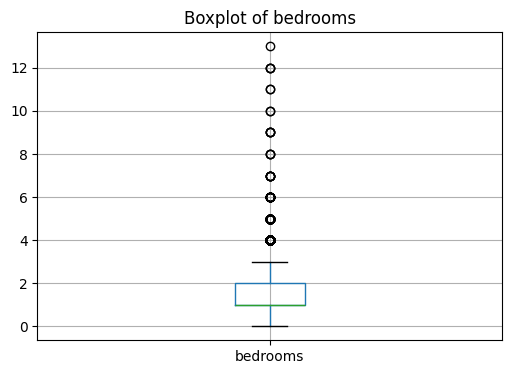

In [199]:
col = 'bedrooms'        # numeric column you check
id_col = 'id'        # identifier column
s = listings[col]
plt.figure(figsize=(6, 4))
listings.boxplot(column=[col])
plt.title(f'Boxplot of {col}')
plt.show()

In [200]:
x = s.dropna()

q1 = x.quantile(0.25)
q3 = x.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (s < lower) | (s > upper)

outliers_beds = listings.loc[outlier_mask, [id_col, col]]
print(outliers_beds, len(outliers_beds))

                        id  bedrooms
34                   83045       5.0
40                  106407       4.0
41                  122324       5.0
76                  249512       4.0
188                 674971       5.0
...                    ...       ...
13011  1484630090593155291       4.0
13031  1486770833416145722       4.0
13068  1492703363216625205       4.0
13150  1500193941020865098       4.0
13207  1507099098746638161       4.0

[397 rows x 2 columns] 397


We checked most places with >10 bedrooms and they are just places with a lot of bedrooms, so the outliers will not be handeld as such.

In [201]:
# missing values are added based on the average of the room type and the number of people the listing accomadetes
listings['bedrooms'] = listings.groupby(
    ['room_type', 'accommodates']
)['bedrooms'].transform(lambda x: x.fillna(x.median()))

1159 0.08736619930649782
count    12107.000000
mean         1.356984
std          0.702807
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         13.500000
Name: bathrooms, dtype: float64


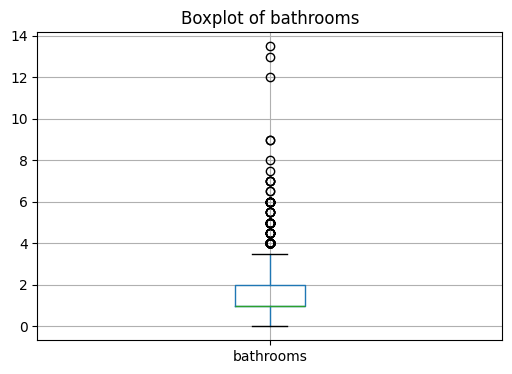

                        id  bathrooms
41                  122324        5.0
76                  249512        4.0
188                 674971        5.5
325                1207304        5.0
340                1261780        4.0
...                    ...        ...
12773  1462473602498877491        6.0
12868  1470887670317858377        7.0
12994  1482464990818085451        4.0
13008  1484073938174359579        5.0
13104  1495535858067851252        4.0

[176 rows x 2 columns] 176


In [202]:
col = 'bathrooms'        # numeric column you check
id_col = 'id'        # identifier column
s = listings[col]
print(s.isna().sum(), s.isna().mean())  # count and fraction of NaNs
print(s.describe())
plt.figure(figsize=(6, 4))
listings.boxplot(column=[col])
plt.title(f'Boxplot of {col}')
plt.show()

x = s.dropna()

q1 = x.quantile(0.25)
q3 = x.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (s < lower) | (s > upper)

outliers_bath = listings.loc[outlier_mask, [id_col, col]]
print(outliers_bath, len(outliers_bath))

In [203]:
common_ids = set(outliers_bath['id']) & set(outliers_beds['id'])
print(len(common_ids))

137


The outliers when it comes to bathrooms are the exact same when it comes to bedrooms, so these are peobably just listings which accomadate more people and therefore have more bathrooms and bedrooms.

In [204]:
# missing values are added based on the average of the room type and the number of people the listing accomadetes
listings['bathrooms'] = listings.groupby(
    ['room_type', 'accommodates']
)['bathrooms'].transform(lambda x: x.fillna(x.median()))

In [205]:
# Price column as numeric 
listings['price'] = (
    listings['price']
      .str.replace('[\$,]', '', regex=True)  # remove $ and commas
      .astype(float)                         # convert to float
)

<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
C:\Users\emily\AppData\Local\Temp\ipykernel_24408\2395443728.py:4: SyntaxWarning: invalid escape sequence '\$'
  .str.replace('[\$,]', '', regex=True)  # remove $ and commas


1173 0.08842152872003618
count    12093.000000
mean       268.054908
std        807.323582
min         10.000000
25%        102.000000
50%        142.000000
75%        215.000000
max      18547.000000
Name: price, dtype: float64


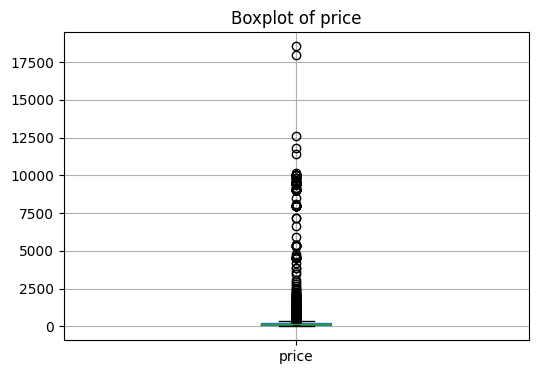

                        id   price
34                   83045   496.0
40                  106407   414.0
76                  249512   964.0
80                  264971   980.0
166                 584756   475.0
...                    ...     ...
13247  1511646524684906450  9000.0
13258  1513710600661172927  8000.0
13263  1514601966798658990  9429.0
13264  1514603753724998674  9429.0
13265  1514605119918326826  9429.0

[1107 rows x 2 columns] 1107


In [206]:
col = 'price'        # numeric column you check
id_col = 'id'        # identifier column
s = listings[col]
print(s.isna().sum(), s.isna().mean())  # count and fraction of NaNs
print(s.describe())

plt.figure(figsize=(6, 4))
listings.boxplot(column=[col])
plt.title(f'Boxplot of {col}')
plt.show()

x = s.dropna()

q1 = x.quantile(0.25)
q3 = x.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (s < lower) | (s > upper)

outliers = listings.loc[outlier_mask, [id_col, col]]
print(outliers, len(outliers))

In [207]:
thr = listings['price'].quantile(0.95)  # top 5%
price_outliers = listings[listings['price'] > thr].copy()
cols = ['price', 'accommodates', 'bedrooms', 'beds',
        'review_scores_rating', 'amenities']

price_outliers[cols].describe()

,price,accommodates,bedrooms,beds,review_scores_rating
count,605.000000,605.000000,605.000000,600.000000,462.000000
mean,2239.137190,5.626446,2.393388,3.265000,4.712143
std,2962.720577,3.089605,1.585517,2.328192,0.364865
min,586.000000,1.000000,0.000000,0.000000,2.330000
25%,777.000000,4.000000,1.000000,2.000000,4.592500
50%,980.000000,5.000000,2.000000,3.000000,4.825000
75%,1523.000000,7.000000,3.000000,4.000000,5.000000
max,18547.000000,16.000000,13.000000,17.000000,5.000000


High prices seem to belong to luxury listings. Thinking about adding a price cap for model accuracy and stability

In [208]:
# it makes no sense to fill the nan values for price as this is our target columns and it will impact the accuracy, 
# so we create a new df with the nan values and drop the nan values from our data df

no_price = listings[listings['price'].isna()].copy()
listings = listings[listings['price'].notna()].copy()

26 0.002150004134623336
count    12067.000000
mean         2.232038
std          1.438625
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         17.000000
Name: beds, dtype: float64


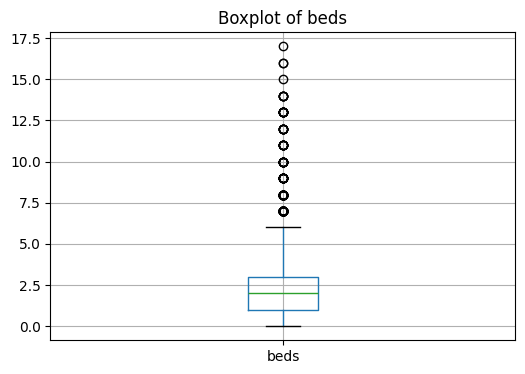

                        id  beds
41                  122324   9.0
48                  141661   7.0
85                  282604   8.0
100                 347062   7.0
170                 611294   8.0
...                    ...   ...
12868  1470887670317858377   7.0
12976  1480486025908852460   8.0
12994  1482464990818085451  12.0
13150  1500193941020865098  11.0
13207  1507099098746638161   8.0

[170 rows x 2 columns] 170


In [209]:
col = 'beds'        # numeric column you check
id_col = 'id'        # identifier column
s = listings[col]
print(s.isna().sum(), s.isna().mean())  # count and fraction of NaNs
print(s.describe())
plt.figure(figsize=(6, 4))
listings.boxplot(column=[col])
plt.title(f'Boxplot of {col}')
plt.show()

x = s.dropna()

q1 = x.quantile(0.25)
q3 = x.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (s < lower) | (s > upper)

outliers_nrbed = listings.loc[outlier_mask, [id_col, col]]
print(outliers_nrbed, len(outliers_nrbed))

In [210]:
common_ids = set(outliers_nrbed['id']) & set(outliers_beds['id'])
print(len(common_ids))

113


In [211]:
# ids in outliers_nrbed but not in common_ids
not_common = set(outliers_nrbed['id']) - common_ids
len(not_common)

57

113 outliers in bed numbers are explained by outliers in bedrooms, if a house has a lot of bedrooms it will have a lot of beds. The other 57 are places where beds can be made from sofas or extra beds, which can be placed in the room, are available. Therefore the outliers are not errors.

In [212]:
# missing values are added based on the average of the number of bedrooms, room type and the number of people the listing accomadetes
listings['beds'] = listings.groupby(
    ['bedrooms', 'accommodates', 'room_type']
)['beds'].transform(lambda x: x.fillna(x.median()))

In [213]:
# it is difficult to fill missing Values when it comes to reviews 
# because there is not a truly neutral score and filling it with
# medians or means distorts the data. So we add a column which is 
# a boolean and shows that the review score was missing before.
# that way if we choose a model which cannot handle nans we can fill 
# the nans with the mean or media review score but they will have the 
# missing note so the model knows that they are not true ratings


listings['review_scores_missing'] = listings['review_scores_rating'].isna().astype(int)

In [214]:
listings.iloc[10:31][['neighbourhood', 'neighborhood_overview', 'neighbourhood_cleansed']]

,neighbourhood,neighborhood_overview,neighbourhood_cleansed
13,"Florence, Tuscany, Italy",The apartment is located in a very quiet area....,Centro Storico
14,"Florence, Tuscany, Italy",The apartment is two minutes from Piazza Pitti.,Centro Storico
15,"Florence, Tuscany, Italy",Florence is a relatively small city full of pe...,Centro Storico
16,"Florence, Tuscany, Italy",Sant’Ambrogio is one of the oldest districts o...,Centro Storico
17,"Florence, Tuscany, Italy","In few minutes you can reach cool shops, tipic...",Centro Storico
19,"Florence, Tuscany, Italy","San Lorenzo Church, the market and Cappelle Me...",Centro Storico
20,"Florence, Tuscany, Italy",The apartment is strategically located a 10 mi...,Centro Storico
21,"Florence, Tuscany, Italy","San Lorenzo Church, the market and Cappelle Me...",Centro Storico
23,"Florence, Tuscany, Italy",The apartment is located in the part of Floren...,Isolotto Legnaia
24,NaN,NaN,Centro Storico


In [215]:
# the neighboorhood column is irrelevant and can be dropped
listings = listings.drop(['neighbourhood'], axis=1)

In [216]:
listings['neighborhood_overview_missing'] = (
    listings['neighborhood_overview'].isna().astype(int)
)
text_nb = listings['neighborhood_overview'].fillna('').astype(str)

listings['nb_overview_len_chars'] = text_nb.str.len()
listings['nb_overview_len_words'] = text_nb.str.split().str.len()

In [217]:
import re
import numpy as np

text_nb = listings['neighborhood_overview'].fillna('').astype(str)

def after_located_near(s):
    s_lower = s.lower()
    idx = s_lower.find('located near')
    if idx == -1:
        return np.nan
    # start right after 'located near'
    start = idx + len('located near')
    # substring from there, strip spaces and punctuation
    snippet = s[start:].strip(" .,:;!-")
    return snippet if snippet else np.nan

listings['nb_after_located_near'] = text_nb.apply(after_located_near)

In [218]:
# categories for the neighbourhood
nb = listings['neighborhood_overview'].fillna('').str.lower()

categories = {
    'nb_cat_transport': [
        'bus', 'tram', 'station', 'train station', 'airport',
        'highway', 'exit', 'connected'
    ],
    'nb_cat_food_places': [
        'restaurant', 'restaurants', 'trattoria', 'trattorias',
        'cafe', 'cafes', 'bar', 'bars', 'pastry shop', 'pizzeria'
    ],
    'nb_cat_shops': [
        'shop', 'shops', 'market', 'supermarket',
        'bakery', 'pharmacy', 'laundry', 'bank'
    ],
    'nb_cat_sights': [
        'duomo', 'ponte vecchio', 'uffizi', 'palazzo pitti',
        'boboli', 'piazzale michelangelo', 'santa croce',
        'arno', 'museum', 'basilica', 'church'
    ],
    'nb_cat_nightlife': [
        'pub', 'pubs', 'night club', 'nightlife',
        'lively', 'clubs', 'fun'
    ],
    'nb_cat_greenery': [
        'park', 'garden', 'gardens', 'green', 'greenery', 'river'
    ],
    'nb_cat_quiet_residential': [
        'quiet', 'residential', 'peaceful', 'safe'
    ]
}

for cat, words in categories.items():
    pattern = '|'.join(r'\b' + re.escape(w) + r'\b' for w in words)
    listings[cat] = nb.str.contains(pattern, na=False).astype(int)

listings = listings.drop(columns=['neighborhood_overview'])

In [219]:
# If it's a string like: {"Wifi", "Kitchen", "Heating"}
def parse_amenities(x):
    if pd.isna(x):
        return []
    # Replace curly braces with square, so ast.literal_eval can parse
    s = x.replace('{', '[').replace('}', ']')
    try:
        vals = ast.literal_eval(s)
    except Exception:
        return []
    # Normalize: lowercase, strip spaces
    return [a.strip().lower() for a in vals]

listings['amenities_list'] = listings['amenities'].apply(parse_amenities)

In [220]:
cnt = Counter()
for ams in listings['amenities_list']:
    cnt.update(ams)

amenities_freq = (
    pd.DataFrame.from_dict(cnt, orient='index', columns=['count'])
    .sort_values('count', ascending=False)
)

amenities_freq.tail(30)

,count
xxx refrigerator,1
"housekeeping available monday, wednesday, friday - available at extra cost",1
jean & len body soap,1
"56 inch hdtv with amazon prime video, netflix, standard cable, dvd player",1
bang & olafsen sound system with bluetooth and aux,1
caleffi stainless steel oven,1
bosh stainless steel gas stove,1
bodycure conditioner,1
bodycure shampoo,1
bodycure body soap,1


In [221]:
amenities = listings['amenities'].fillna('').str.lower()
def count_matches(text):
    return sum(1 for pat in patterns if pat.search(text) is not None)

categories = {
    # Important single amenities (1/0 flags)
    'am_wifi': ['wifi'],
    'am_hotwater': ['hot water'],
    'am_kitchen': ['kitchen'],
    'am_heating': ['heating'],
    'am_air_conditioning': ['air conditioning'],
    'am_tv': ['tv'],
    'am_bidet': ['bidet'],
    'am_parking': ['free parking'],
    'am_housekeeping': ['housekeeping'],

    # Equipped scores per category (count how many of these each listing has)
    'am_score_kitchen': [
        'cooking basics', 'microwave', 'dishwasher',
        'refrigerator', 'freezer', 'oven', 'dishes and silverware',
        'wine glasses', 'hot water kettle', 'dining table', 'coffee',
        'stove', 'toaster'
    ],
    'am_score_bath_toiletries': [
        'shampoo', 'shower gel', 'body soap', 'soap',
        'conditioner', 'hair dryer'
    ],
    'am_score_comfort': [
        'bed linens', 'extra pillows and blankets', 'room darkening shades'
    ],
    'am_score_safety': [
        'smoke alarm', 'carbon monoxide alarm', 'fire extinguisher',
        'first aid kit', 'safe'
    ],
    'am_score_laundry_cleaning': [
        'washer', 'dryer', 'iron', 'cleaning products', 'drying rack for clothing'
    ],
    'am_score_workspace': [
        'dedicated workspace', 'desk'
    ]
}

for col, words in categories.items():
    # precompile regexes with word boundaries to avoid partial matches
    patterns = [re.compile(r'\b' + re.escape(w) + r'\b') for w in words]


    listings[col] = amenities.apply(count_matches).astype(int)

In [222]:
cols = [c for c in listings.columns if c.startswith('am_') or c == 'amenities_count']
listings[cols].head()

,am_wifi,am_hotwater,am_kitchen,am_heating,am_air_conditioning,am_tv,am_bidet,am_parking,am_housekeeping,am_score_kitchen,am_score_bath_toiletries,am_score_comfort,am_score_safety,am_score_laundry_cleaning,am_score_workspace
0,1,1,1,1,1,0,1,0,0,6,3,1,3,2,0
1,1,1,1,1,0,1,0,0,0,7,1,0,2,3,0
2,1,1,0,1,1,1,1,0,0,0,5,2,1,1,1
4,1,1,1,1,1,1,1,0,0,10,6,2,2,5,1
6,1,1,1,1,1,1,1,0,0,12,6,2,4,5,1


In [223]:
listings['amenities_count'] = listings['amenities_list'].str.len()
listings['amenities_count'].describe()

count    12093.000000
mean        33.741917
std         13.070737
min          0.000000
25%         25.000000
50%         34.000000
75%         43.000000
max         95.000000
Name: amenities_count, dtype: float64

In [225]:
listings.to_csv("data/listings_features.csv", index=False)